# Week 1 Thu: Descriptive statistics, sampling intuition, and visualizing market data

Estimated time: 10 hours

## Why this matters
Before any model, a quant needs to understand the shape of the data: center, spread, skew, and outliers.

## Study blocks
- Block 1 (60 min): Concept briefing and key-assumption mapping.
- Block 2 (60 min): Formula/workflow derivation and notation rewrite.
- Block 3 (60 min): Solved real-world case walkthrough.
- Block 4 (60 min): Data checks and exploratory diagnostics.
- Block 5 (60 min): Core notebook implementation with comments.
- Block 6 (60 min): Extension coding task and sensitivity variation.
- Block 7 (60 min): Risk caveat and robustness scenario testing.
- Block 8 (60 min): Interview-style quiz answers and defense drill.
- Block 9 (60 min): Revision sprint and error-log updates.
- Block 10 (60 min): Desk memo summary and tomorrow transition plan.

## Concept notes
### Mean and median
The mean is the average. The median is the middle value after sorting.

Technical note: The sample mean is sensitive to extreme values, while the median is more robust when data contain outliers.

Finance example: A few crisis days can drag the mean return down sharply even if most days were calm.

### Variance and standard deviation
These measure how spread out the data are. Standard deviation is easier to interpret because it is in the same units as the original data.

Technical note: For returns, standard deviation is commonly used as a volatility proxy. High volatility means outcomes vary more around the average.

Finance example: Two assets can have the same average return but very different standard deviations, leading to very different risk profiles.

### Sampling uncertainty
A sample average is only an estimate. A different sample might give a different number.

Technical note: In finance, short samples are noisy. Apparent performance may be mostly sampling variation rather than genuine edge.

Finance example: A backtest with 20 trades may look amazing mostly because of luck.


## Code Lab 1: Summary statistics

In [1]:
import pandas as pd

returns = pd.Series([0.01, 0.02, -0.01, 0.00, 0.03, -0.02, 0.01], name="returns")
summary = pd.Series(
    {
        "mean": returns.mean(),
        "median": returns.median(),
        "std": returns.std(),
        "min": returns.min(),
        "max": returns.max(),
    }
)
print(summary.round(4))


mean      0.0057
median    0.0100
std       0.0172
min      -0.0200
max       0.0300
dtype: float64


## Code Lab 2: Visualization

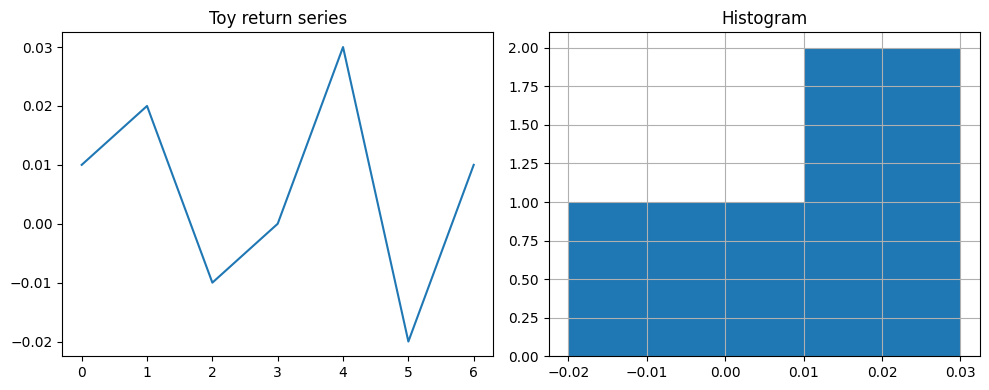

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
returns.plot(ax=axes[0], title="Toy return series")
returns.hist(ax=axes[1], bins=5)
axes[1].set_title("Histogram")
plt.tight_layout()
plt.show()


## Practice recap
- Why can two assets with the same mean return still feel very different to hold?
  Suggested answer: Because their volatility and downside behavior can differ a lot, changing drawdown and risk management demands.
- Why is standard deviation often preferred over variance in communication?
  Suggested answer: Because it is in the same scale as the original data, making it easier to interpret.
- Why should a quant look at plots before modeling?
  Suggested answer: Plots can reveal trends, outliers, missing values, and changing volatility that summary statistics alone may hide.

## Interview drill
- Q: What does volatility mean in practice?
  A: It is a measure of dispersion in returns and is often used as a simple proxy for how noisy or risky an asset is.
- Q: Why is the sample mean dangerous in finance?
  A: Because financial data are noisy, non-stationary, and heavily influenced by outliers and regime changes.

## 10-Hour Completion Roadmap

Use this minimum structure to turn today's notebook into a serious study session:

- Phase 1 (60 min): Read concept notes and rewrite the core idea from memory.
- Phase 2 (60 min): Rewrite formulas/workflows and define each term.
- Phase 3 (60 min): Complete baseline code labs with comments.
- Phase 4 (60 min): Build one real-data extension and compare outputs.
- Phase 5 (60 min): Add stress/sensitivity checks and interpret shifts.
- Phase 6 (60 min): Run scenario analysis and identify fragile assumptions.
- Phase 7 (60 min): Complete interview-style Python drill with explanation.
- Phase 8 (60 min): Do closed-book retrieval and update error log.
- Phase 9 (60 min): Write one desk memo with recommendation and caveat.
- Phase 10 (60 min): Define next-session experiment plan and confidence score.

## Formula Rewrite Drill

In [3]:
import pandas as pd

formula_drill = pd.DataFrame(
    [{'formula': '\\bar x=\\frac{1}{n}\\sum_{i=1}^n x_i', 'from_memory': '', 'term_explanations': ''}, {'formula': 's=\\sqrt{\\frac{1}{n-1}\\sum_{i=1}^n(x_i-\\bar x)^2}', 'from_memory': '', 'term_explanations': ''}, {'formula': 'z=\\frac{x-\\mu}{\\sigma}', 'from_memory': '', 'term_explanations': ''}]
)
print(formula_drill)


                                            formula from_memory  \
0                \bar x=\frac{1}{n}\sum_{i=1}^n x_i               
1  s=\sqrt{\frac{1}{n-1}\sum_{i=1}^n(x_i-\bar x)^2}               
2                            z=\frac{x-\mu}{\sigma}               

  term_explanations  
0                    
1                    
2                    


## Real Market Data Lab (Topic-Aligned)

        Use today's topic (Descriptive statistics, sampling intuition, and visualizing market data) with one concrete dataset and one measurable output.

        - Use curriculum/datasets/real_market_prices.csv as reproducible fallback data.
- Build one table and one chart supporting a decision.
- Document one limitation and one robustness check.

In [4]:
TASK = 'Compute log returns and summarize annualized return/risk with one caveat.'
print('Lab task:', TASK)

from pathlib import Path
import pandas as pd

market = pd.read_csv(Path("curriculum/datasets/real_market_prices.csv"), parse_dates=["date"])
prices = market.pivot(index="date", columns="symbol", values="close").dropna()
ret = prices.pct_change().dropna()
ann_ret = ret.mean() * 252
ann_vol = ret.std() * (252 ** 0.5)
print(pd.DataFrame({"ann_return": ann_ret, "ann_vol": ann_vol}).round(4))


Lab task: Compute log returns and summarize annualized return/risk with one caveat.
        ann_return  ann_vol
symbol                     
GLD         0.1856   0.1770
QQQ         0.1719   0.2247
SPY         0.1524   0.1698
TLT        -0.0683   0.1579


## Real-World Takeaway Prompt

Write 5-8 lines for today's topic (Descriptive statistics, sampling intuition, and visualizing market data):

1. Which symbol looked most volatile and why that matters.
2. Which pair looked most diversifying.
3. One realistic portfolio/risk decision you could make from this table.

## Interview Question + Python Solution Drill

Use this format for interview preparation:

1. State the question clearly.
2. Explain your approach in plain language.
3. Write Python code on relevant data.
4. Interpret one risk caveat in words.

**Drill prompt**
- Compute log returns and summarize annualized return/risk with one caveat.

In [5]:
TASK = 'Compute log returns and summarize annualized return/risk with one caveat.'
print('Interview drill task:', TASK)

from pathlib import Path
import pandas as pd

market = pd.read_csv(Path("curriculum/datasets/real_market_prices.csv"), parse_dates=["date"])
prices = market.pivot(index="date", columns="symbol", values="close").dropna()
ret = prices.pct_change().dropna()
ann_ret = ret.mean() * 252
ann_vol = ret.std() * (252 ** 0.5)
print(pd.DataFrame({"ann_return": ann_ret, "ann_vol": ann_vol}).round(4))


Interview drill task: Compute log returns and summarize annualized return/risk with one caveat.
        ann_return  ann_vol
symbol                     
GLD         0.1856   0.1770
QQQ         0.1719   0.2247
SPY         0.1524   0.1698
TLT        -0.0683   0.1579


## Extended 10-Hour Coding Challenge

Build one additional variant for today's topic (Descriptive statistics, sampling intuition, and visualizing market data):

1. Change one key assumption or parameter.
2. Re-run the pipeline and compare baseline vs variant.
3. Comment each major step in code so another analyst can audit your logic.
4. State whether the recommendation changed and why.

In [6]:
import pandas as pd

baseline_vs_variant = pd.DataFrame(
    [
        {"run": "baseline", "key_assumption": "", "headline_metric": None, "decision": ""},
        {"run": "variant", "key_assumption": "", "headline_metric": None, "decision": ""},
    ]
)

# Fill this table after running your variant so the comparison is explicit.
print(baseline_vs_variant)


        run key_assumption headline_metric decision
0  baseline                           None         
1   variant                           None         


## Scenario Analysis Drill

In [7]:
import pandas as pd

scenarios = pd.DataFrame(
    [
        {"scenario": "base_case", "assumption": "", "expected_effect": ""},
        {"scenario": "bull_case", "assumption": "", "expected_effect": ""},
        {"scenario": "stress_case", "assumption": "", "expected_effect": ""},
    ]
)
print("Topic:", 'Descriptive statistics, sampling intuition, and visualizing market data')
print(scenarios)


Topic: Descriptive statistics, sampling intuition, and visualizing market data
      scenario assumption expected_effect
0    base_case                           
1    bull_case                           
2  stress_case                           


## Closed-Book Retrieval and Error Log

In [8]:
import pandas as pd

retrieval_scorecard = pd.DataFrame(
    [
        {"prompt": "Explain today's concept in 3 lines", "score_0_to_5": None, "notes": ""},
        {"prompt": "Write one key formula without notes", "score_0_to_5": None, "notes": ""},
        {"prompt": "Give one realistic failure mode", "score_0_to_5": None, "notes": ""},
        {"prompt": "Connect to one trading/risk decision", "score_0_to_5": None, "notes": ""},
    ]
)

error_log = pd.DataFrame(
    [
        {
            "concept": "",
            "mistake": "",
            "correction": "",
            "next_review_date": "",
        }
    ]
)
print("Retrieval scorecard template:")
print(retrieval_scorecard)
print("\nError log template:")
print(error_log)


Retrieval scorecard template:
                                 prompt score_0_to_5 notes
0    Explain today's concept in 3 lines         None      
1   Write one key formula without notes         None      
2       Give one realistic failure mode         None      
3  Connect to one trading/risk decision         None      

Error log template:
  concept mistake correction next_review_date
0                                            


## Final 30-Minute Deliverable

Write a short memo (150-250 words) with this structure:

1. Core idea of Descriptive statistics, sampling intuition, and visualizing market data in plain language.
2. One technical detail or formula and why it matters.
3. One practical quant use case.
4. One limitation or failure mode and how you would detect it.